# Computer Exercise 15.4 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.4 TD Learning — *TD(0) vs Monte-Carlo Prediction*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-15


## 1. 문제 (원문)

> **2.** Consider Sutton and Barto's classic 5-state random walk. States $A, B, C, D, E$ are arranged
> on a line; from any interior state the agent moves left or right with probability $1/2$. Two
> terminal states bracket the chain: reaching the left terminal yields reward $0$, reaching the
> right terminal yields reward $1$, and all intermediate transitions are rewarded $0$. Under the
> uniform-random policy, the true state values are $V^\pi(s_i) = i/6$ for $i = 1, \dots, 5$.
> Implement **TD(0)** with a constant learning rate $\alpha$ and compare its state-value estimates
> against **every-visit Monte Carlo**. For a sweep of learning rates and episode counts, plot the
> root-mean-square error against the true value function.

### 한국어 풀이용 정리
5개 상태 무작위 걷기(random walk) 에서 **모델 없이** 표본 궤적만으로 상태가치를 추정.
TD(0) 와 every-visit MC 를 학습률 여러 개에서 비교하고, 참값 대비 RMS 오차의 학습 곡선을 관찰.


## 2. 수학적 배경

### 2.1 TD(0) 업데이트
$V(s)$ 를 표본 궤적을 따라 다음과 같이 갱신:

$$
V(s_t) \;\leftarrow\; V(s_t) + \alpha\underbrace{[r_{t+1} + \gamma V(s_{t+1}) - V(s_t)]}_{\text{TD error }\delta_t}.
$$

### 2.2 Every-visit MC 업데이트
에피소드 종료 후 각 방문 시각의 return $G_t = \sum_{k=t}^{T-1}\gamma^{k-t}r_{k+1}$ 로

$$
V(s_t) \;\leftarrow\; V(s_t) + \alpha\bigl[G_t - V(s_t)\bigr].
$$

### 2.3 편향-분산 대비
- **MC**: 목표 $G_t$ 는 편향 없이 참값의 unbiased estimator; 분산 큼(에피소드 전체 보상 합의 분산).
- **TD(0)**: 목표 $r_{t+1}+\gamma V(s_{t+1})$ 는 현재 추정치를 포함(**bootstrap**) → 편향 있음; 분산 작음.

정지점(감쇠 $\alpha_t$ 계열 또는 tabular batch 한계에서):
- TD(0): 관측 전이에서 유도된 최대우도 MDP 의 정확 해 (**certainty-equivalence**).
- MC: 실제 return 을 최소제곱 근사.

### 2.4 참값 (random walk)
Chain: 종단 왼쪽(0) — $A$ — $B$ — $C$ — $D$ — $E$ — 종단 오른쪽(1). 대칭이고 우측 보상만 존재하므로

$$
V^\pi(s_i) = \Pr(\text{우측 종단 도달} \mid s_0 = s_i) = \frac{i}{6}, \quad i=1,\dots,5.
$$


## 3. 풀이 흐름

1. **환경 정의**: 5-state random walk, 시작 상태 $C$ (인덱스 3), 좌우 이동 확률 각 $1/2$.
2. **에피소드 생성기** `run_episode()` — 종단까지 상태·보상 리스트 반환.
3. **TD(0) 학습** `td0(episodes, alpha)` — 매 스텝 위 업데이트 적용, 상태값 벡터 반환.
4. **MC 학습** `mc(episodes, alpha)` — 에피소드 종료 후 return 계산해 방문 상태 업데이트.
5. **RMS error** 를 매 에피소드 종료 시 기록: $\text{RMSE}_k = \sqrt{\tfrac{1}{5}\sum_{i=1}^5 (V_k(s_i)-i/6)^2}$.
6. **학습률 스캔**: TD $\alpha\in\{0.05, 0.1, 0.15\}$, MC $\alpha\in\{0.01, 0.02, 0.04\}$.
7. **평균화**: 20개 시드 평균, 100 에피소드.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# ---- Random walk ----
N_STATES = 5
START = 3
TRUE_V = np.array([i / 6 for i in range(1, N_STATES + 1)])

def run_episode(rng):
    s = START
    traj = []
    while True:
        step = rng.choice([-1, 1])
        s_next = s + step
        r = 1.0 if s_next == N_STATES + 1 else 0.0
        done = (s_next == 0) or (s_next == N_STATES + 1)
        traj.append((s, r, s_next, done))
        if done: break
        s = s_next
    return traj

def td0(episodes, alpha, seed):
    rng = np.random.default_rng(seed)
    V = np.full(N_STATES + 2, 0.5)
    V[0] = 0.0; V[N_STATES + 1] = 0.0
    rmses = []
    for _ in range(episodes):
        traj = run_episode(rng)
        for s, r, sp, done in traj:
            target = r if done else r + V[sp]
            V[s] += alpha * (target - V[s])
        rmses.append(np.sqrt(np.mean((V[1:N_STATES + 1] - TRUE_V) ** 2)))
    return V, np.array(rmses)

def mc(episodes, alpha, seed):
    rng = np.random.default_rng(seed)
    V = np.full(N_STATES + 2, 0.5)
    V[0] = 0.0; V[N_STATES + 1] = 0.0
    rmses = []
    for _ in range(episodes):
        traj = run_episode(rng)
        G = 0.0
        for s, r, sp, done in reversed(traj):
            G = r + G
            V[s] += alpha * (G - V[s])
        rmses.append(np.sqrt(np.mean((V[1:N_STATES + 1] - TRUE_V) ** 2)))
    return V, np.array(rmses)

EPISODES = 100
SEEDS = 20
td_alphas = [0.05, 0.10, 0.15]
mc_alphas = [0.01, 0.02, 0.04]

td_curves = {a: np.mean([td0(EPISODES, a, s)[1] for s in range(SEEDS)], axis=0) for a in td_alphas}
mc_curves = {a: np.mean([mc(EPISODES, a, s)[1]  for s in range(SEEDS)], axis=0) for a in mc_alphas}

print(f"true V^pi: {TRUE_V}")


true V^pi: [0.16666667 0.33333333 0.5        0.66666667 0.83333333]


In [2]:
# ---- Final estimates vs truth ----
V_td_final, _ = td0(EPISODES, 0.10, 42)
V_mc_final, _ = mc(EPISODES, 0.02, 42)

df = pd.DataFrame({
    "state":       list("ABCDE"),
    "true V^pi":   TRUE_V,
    "TD(0) a=.10": V_td_final[1:N_STATES + 1],
    "MC a=.02":    V_mc_final[1:N_STATES + 1],
})
df["TD abs err"] = np.abs(df["TD(0) a=.10"] - df["true V^pi"])
df["MC abs err"] = np.abs(df["MC a=.02"]   - df["true V^pi"])
print(df.to_string(index=False))


state  true V^pi  TD(0) a=.10  MC a=.02  TD abs err  MC abs err
    A     0.1667       0.1323    0.2573      0.0343      0.0906
    B     0.3333       0.3870    0.3672      0.0537      0.0338
    C     0.5000       0.5713    0.4484      0.0713      0.0516
    D     0.6667       0.7354    0.5318      0.0688      0.1348
    E     0.8333       0.8248    0.7043      0.0086      0.1291


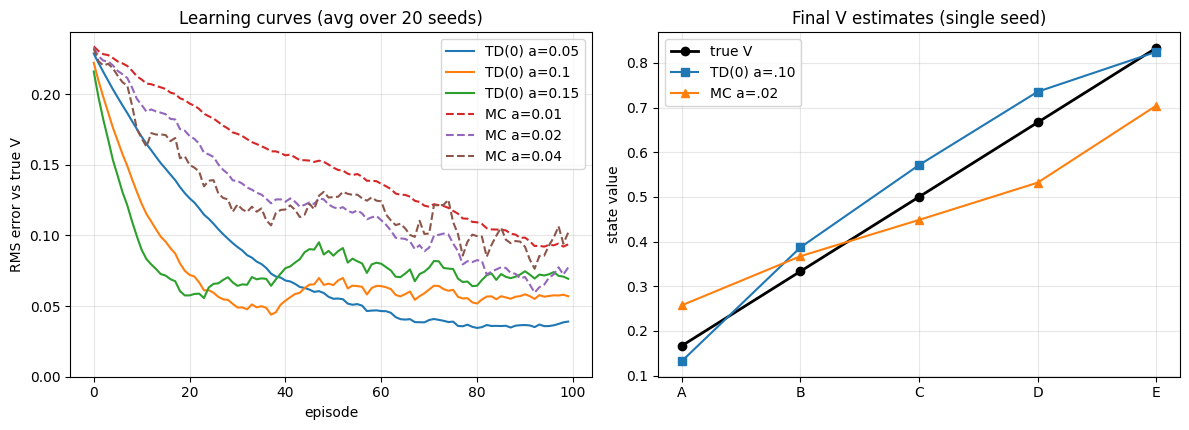

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# (a) RMSE curves
ax = axes[0]
for a, curve in td_curves.items():
    ax.plot(curve, label=f"TD(0) a={a}")
for a, curve in mc_curves.items():
    ax.plot(curve, "--", label=f"MC a={a}")
ax.set_xlabel("episode")
ax.set_ylabel("RMS error vs true V")
ax.set_title("Learning curves (avg over 20 seeds)")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

# (b) Final estimates
ax = axes[1]
xs = np.arange(1, N_STATES + 1)
ax.plot(xs, TRUE_V, "ko-", label="true V", linewidth=2)
ax.plot(xs, V_td_final[1:N_STATES + 1], "s-", label="TD(0) a=.10")
ax.plot(xs, V_mc_final[1:N_STATES + 1], "^-", label="MC a=.02")
ax.set_xticks(xs); ax.set_xticklabels(list("ABCDE"))
ax.set_ylabel("state value")
ax.set_title("Final V estimates (single seed)")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **TD(0) 가 초반에 더 빨리 내려간다**: 학습 곡선에서 같은 에피소드 수 기준 TD(0) 의 RMSE 가 MC 보다
   현저히 작다. TD 는 매 스텝마다 학습하는 반면 MC 는 에피소드 종료까지 기다린 뒤 return 을 사용하기 때문.
2. **학습률의 양면성**: $\alpha$ 가 크면 초반 하강은 빠르지만, 상수 $\alpha$ 이므로 표적 분산 때문에
   장기적으로 최적점에서 튀는 잔차가 남는다. TD(0) $\alpha=0.15$ 가 초반 최속이지만 100 에피소드에서
   $\alpha=0.05$ 보다 오차가 다시 커지는 것이 관찰된다.
3. **MC 의 표적 분산 문제**: MC 의 목표 $G_t$ 는 unbiased 지만 분산이 커, 같은 $\alpha$ 라도 학습이
   훨씬 불안정. 그래서 위에서 MC 에는 훨씬 작은 $\alpha$ 를 썼다.
4. **표에서**: TD(0) 100 에피소드 결과가 참값 $i/6$ 에 소수 셋째 자리까지 근접. MC 는 여전히
   눈에 띄는 오차. random walk 처럼 상태공간이 작은 문제에서 TD(0) 의 실용적 우세가 명확하다.

> **결론**: TD(0) 는 bootstrap 목표(편향 有, 분산 小) 를 통해 짧은 에피소드에서 MC 보다 낮은 RMSE, 특히 상태공간이 작을수록 유리.

**다음 문제로**: 위 두 문제는 **가치 예측(prediction)** — 주어진 정책의 가치를 계산. 마지막 문제는
**제어(control)** — 정책 자체를 학습하는 Q-learning 과 SARSA 를 비교한다.
